In [1]:
import os
import sys
import numpy as np
import pandas as pd
import nibabel as nib
import nilearn
from nilearn.image import resample_img
from nilearn import plotting
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from nilearn import masking
# from natsort import natsorted
import pickle

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import matplotlib.pyplot as plt
from scipy.stats import zscore

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import KFold
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
maskDir = 'N:\Experimental_Data\yujunchen\projects\data\masks'
maskFile = os.path.join(maskDir, 'MNI152_T1_2mm_brain_mask.nii.gz')
mask = nib.load(maskFile)
temp_nii_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\\betas\Sub1\\beta_0001.nii'
temp_nii_data = nib.load(temp_nii_path)
# Resample the MNI mask to match the dimensions and voxel size of your NIfTI file
resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
resampled_mask.shape

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_40496\4267585830.py:7: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_40496\4267585830.py:7: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_mask = resample_img(mask, target_affine=temp_nii_data.affine, target_shape=temp_nii_data.shape)


(79, 95, 79)

In [10]:
# Read the stimuli information for the 600 trials
stimuli = pd.read_csv("./stimuli_600trials.csv")
stimuli

,run,OriginalOrder,img,emotion_type,AI,group
0,1,0,2045_2.jpg,pleasant,YES,pleasantAI
1,1,1,6211_0.jpg,unpleasant,YES,unpleasantAI
2,1,2,5395_2.jpg,neutral,YES,neutralAI
3,1,3,3230_0.jpg,unpleasant,YES,unpleasantAI
4,1,4,2550.jpg,pleasant,NO,pleasant
...,...,...,...,...,...,...
595,10,595,3016_1.jpg,unpleasant,YES,unpleasantAI
596,10,596,9140.jpg,unpleasant,NO,unpleasant
597,10,597,2446.jpg,neutral,NO,neutral
598,10,598,9570_1.jpg,unpleasant,YES,unpleasantAI


In [3]:
# Load the dictionary from the file
with open('kastner_dict.pkl', 'rb') as f:
    roi_masks = pickle.load(f)


In [4]:
for (k, v) in roi_masks.items():
    print(k, v.get_fdata().shape, np.count_nonzero(v.get_fdata()))

V1v (79, 95, 79) 856
V1d (79, 95, 79) 748
V2v (79, 95, 79) 727
V2d (79, 95, 79) 645
V3v (79, 95, 79) 527
V3d (79, 95, 79) 517
hV4 (79, 95, 79) 328
V3a (79, 95, 79) 554
V3b (79, 95, 79) 263
LO1 (79, 95, 79) 324
LO2 (79, 95, 79) 125
VO1 (79, 95, 79) 153
VO2 (79, 95, 79) 253
IPS (79, 95, 79) 973
PHC1 (79, 95, 79) 175
PHC2 (79, 95, 79) 165


In [6]:
beta_idx = []
for i in range(0 ,10): # runs
    id = [(x + 66*i) for x in range(1,61)]
    beta_idx.append(id)
beta_id = np.array(beta_idx).reshape(1, -1)
beta_id

array([[  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  67,  68,  69,  70,  71,
         72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
         85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
        111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
        124, 125, 126, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181,
        182, 183, 184, 185, 186, 187, 188, 189, 190

In [5]:
dataDir = '../GLM_singletrial/betas/'
subs = ['Sub31']

# Loop through each subject and assert their existence
for sub in subs:
    sub_path = os.path.join(dataDir, sub)
    if not os.path.isdir(sub_path):
        raise FileNotFoundError(f"Folder for {sub} does not exist at path: {sub_path}")
    else:
        print(f"Folder for {sub} exists at path: {sub_path}")

Folder for Sub31 exists at path: ../GLM_singletrial/betas/Sub31


In [7]:
import os
import re
import nibabel as nib
import numpy as np
from nilearn import masking
from tqdm import tqdm

# -------------------------------
# Configuration
# -------------------------------
dataDir = 'N:/Experimental_Data/yujunchen/projects/AI_IAPS/GLM_singletrial/betas/'
subs =  ['Sub31']

out_dir = r"N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\data\30subs"
os.makedirs(out_dir, exist_ok=True)
# -------------------------------
# Processing
# -------------------------------
beta_series = []

for sub in subs:
    sub_dir = os.path.join(dataDir, sub)
    filenames = os.listdir(sub_dir)

    # ✅ Strictly keep only files matching "beta_<number>.nii"
    beta_filenames = [f for f in filenames if re.match(r'^beta_\d+\.nii$', f)]
    file_ids = [int(re.findall(r'\d+', f)[0]) for f in beta_filenames]

    # Select only files whose numeric ID is in beta_id
    selected_filenames = [f for f, fid in zip(beta_filenames, file_ids) if fid in beta_id]

    # Sort numerically (important for sequential betas)
    selected_filenames = sorted(selected_filenames, key=lambda x: int(re.findall(r'\d+', x)[0]))

    print(f'[{sub}] Number of beta files to load: {len(selected_filenames)}')

    sub_beta_series = []

    for fname in tqdm(selected_filenames, desc=f'Loading {sub}'):
        file_path = os.path.join(sub_dir, fname)

        # Load beta image
        nii_data = nib.load(file_path)

        # Apply brain mask
        masked_data = masking.apply_mask(nii_data, resampled_mask)

        # Create full-size 3D volume with NaNs outside the mask
        reshaped_data = np.full(nii_data.shape, np.nan, dtype=np.float32)
        mask_indices = np.where(resampled_mask.get_fdata())
        reshaped_data[mask_indices] = masked_data

        sub_beta_series.append(reshaped_data)

    # Stack into one 4D array (n_betas, x, y, z)
    sub_beta_arrays = np.array(sub_beta_series, dtype=np.float32)
    beta_series.append(sub_beta_arrays)
    print(f'[{sub}] Loaded shape: {sub_beta_arrays.shape}')
    
    beta_path = os.path.join(out_dir, f"{sub}_beta.npy")
    np.save(beta_path, sub_beta_arrays.astype(np.float32))
    print(f"Saved {sub}: beta -> {beta_path}")



[Sub31] Number of beta files to load: 600


Loading Sub31: 100%|██████████| 600/600 [03:53<00:00,  2.57it/s]


[Sub31] Loaded shape: (600, 79, 95, 79)
Saved Sub31: beta -> N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\data\30subs\Sub31_beta.npy


In [14]:
beta_series = np.array(beta_series, dtype=np.float32)  # shape: (n_subs, n_betas, x, y, z)
beta_flat = beta_series.reshape(beta_series.shape[0], beta_series.shape[1], -1)
beta_flat.shape

(1, 600, 592895)

In [15]:
import numpy as np
import pandas as pd

assert isinstance(stimuli, pd.DataFrame), "Failed to read stimuli CSV."
assert len(stimuli) == beta_flat.shape[1], "stimuli rows must match beta_flat trials (600)."

# Fix common typos if present
stimuli = stimuli.copy()

group_order = ['pleasant', 'neutral', 'unpleasant',
               'pleasantAI', 'neutralAI', 'unpleasantAI']

# Enforce the category order (helps downstream sorting)
stimuli['group'] = pd.Categorical(stimuli['group'],
                                  categories=group_order,
                                  ordered=True)

# 1) Build the 120 groups of indices (one per unique image, 5 repeats each)
index_groups = []   # list of np.array of length 5 (trial indices)
labels = []         # parallel list of (group, img)
problems = []

for g in group_order:
    gdf = stimuli[stimuli['group'] == g]
    # preserve first-appearance order of each image within the group
    img_order = gdf.drop_duplicates(subset='img', keep='first')['img'].tolist()

    if len(img_order) != 20:
        problems.append(f"[{g}] expected 20 unique imgs, found {len(img_order)}")

    for img in img_order:
        idx = gdf.index[gdf['img'] == img].to_numpy()
        if len(idx) != 5:
            problems.append(f"[{g}, {img}] expected 5 repeats, found {len(idx)}")
        index_groups.append(idx)
        labels.append((g, img))

if problems:
    raise ValueError("Data integrity issues:\n" + "\n".join(problems))

assert len(index_groups) == 120, f"Expected 120 averaged units, got {len(index_groups)}"

# 2) Average across the 5 repeats per (group,img), per subject, per voxel
S, T, V = beta_flat.shape
beta_flat_avg = np.empty((S, 120, V), dtype=beta_flat.dtype)

for j, idx in enumerate(index_groups):
    # beta_flat[:, idx, :] -> (30, 5, 592895); average across repeats
    beta_flat_avg[:, j, :] = np.nanmean(beta_flat[:, idx, :], axis=1)

# 3) Metadata mapping columns -> (group, img, original trial indices)
avg_meta = pd.DataFrame({
    'out_col': np.arange(120, dtype=int),
    'group'  : [g for g, _ in labels],
    'img'    : [img for _, img in labels],
    'trial_indices': [idx for idx in index_groups],
})
avg_meta['group'] = pd.Categorical(avg_meta['group'],
                                   categories=group_order,
                                   ordered=True)
avg_meta = avg_meta.sort_values(['group', 'out_col']).reset_index(drop=True)

print("beta_flat_avg shape:", beta_flat_avg.shape)   # (30, 120, 592895)
print(avg_meta.head())


beta_flat_avg shape: (1, 120, 592895)
   out_col     group       img             trial_indices
0        0  pleasant  2550.jpg   [4, 174, 328, 428, 570]
1        1  pleasant  4505.jpg  [18, 185, 272, 398, 529]
2        2  pleasant  2314.jpg  [19, 186, 273, 435, 567]
3        3  pleasant  4597.jpg  [26, 208, 249, 446, 507]
4        4  pleasant  4180.jpg  [30, 157, 268, 454, 542]


In [19]:
selected_subs = list(range(beta_flat_avg.shape[0]))  # all subjects

IndexError: index 4 is out of bounds for axis 0 with size 4

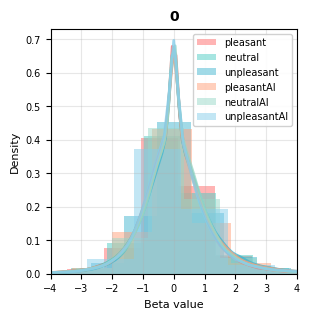

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_subject_distributions(beta_flat_avg, avg_meta, selected_subs):
    """
    Create 5x6 subplot figure with beta-value distributions for each subject
    Each subplot shows 6 distributions (one per condition) in different colors
    """
    
    # Define colors for each condition
    condition_colors = {
        'pleasant': '#FF6B6B',      # Red
        'neutral': '#4ECDC4',       # Teal
        'unpleasant': '#45B7D1',    # Blue
        'pleasantAI': '#FFA07A',    # Light Red
        'neutralAI': '#98D8C8',     # Light Teal
        'unpleasantAI': '#87CEEB'   # Sky Blue
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(7, 7))
    axes = axes.flatten()
    
    group_order = ['pleasant', 'neutral', 'unpleasant', 
                   'pleasantAI', 'neutralAI', 'unpleasantAI']
    
    for subj_idx in range(len(selected_subs)):
        ax = axes[subj_idx]
        condition_data = {}
        
        for group in group_order:
            group_mask = avg_meta['group'] == group
            group_indices = np.where(group_mask)[0]
            group_beta_values = beta_flat_avg[subj_idx, group_indices, :].flatten()
            group_beta_values = group_beta_values[~np.isnan(group_beta_values)]
            
            if len(group_beta_values) > 100000:
                np.random.seed(42)
                group_beta_values = np.random.choice(group_beta_values, 100000, replace=False)
            
            condition_data[group] = group_beta_values
        
        for group in group_order:
            if len(condition_data[group]) > 0:
                ax.hist(condition_data[group],
                        bins=20,
                        alpha=0.5,
                        color=condition_colors[group],
                        label=group,
                        density=True,
                        histtype='stepfilled')
                
                from scipy import stats
                density = stats.gaussian_kde(condition_data[group])
                xs = np.linspace(condition_data[group].min(),
                                 condition_data[group].max(), 200)
                ax.plot(xs, density(xs), color=condition_colors[group],
                        linewidth=2, alpha=0.8)
        
        ax.set_title(f'{selected_subs[subj_idx]}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Beta value', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_xlim(-4, 4)
        ax.grid(True, alpha=0.3)
        
        if subj_idx == 0:
            ax.legend(loc='upper right', fontsize=7, framealpha=0.9)
    
    for i in range(len(selected_subs), 30):
        axes[i].set_visible(False)
    
    fig.suptitle('Beta Value Distributions by Subject and Condition',
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.savefig('subject_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary stats
    print("\n" + "="*60)
    print("DISTRIBUTION SUMMARY STATISTICS")
    print("="*60)
    for subj_idx in range(min(3, len(selected_subs))):
        print(f"\n{selected_subs[subj_idx]}:")
        for group in group_order:
            group_mask = avg_meta['group'] == group
            group_indices = np.where(group_mask)[0]
            group_beta_values = beta_flat_avg[subj_idx, group_indices, :].flatten()
            group_beta_values = group_beta_values[~np.isnan(group_beta_values)]
            
            if len(group_beta_values) > 0:
                print(f"  {group:15s}: mean={np.mean(group_beta_values):6.3f}, "
                      f"std={np.std(group_beta_values):6.3f}, "
                      f"n={len(group_beta_values):,}")

# Create the plot
plot_subject_distributions(beta_flat_avg, avg_meta, selected_subs)


In [34]:
import os
import numpy as np
import pandas as pd
import nibabel as nib

# ------------------------------------------------------------
# REQUIRED INPUTS
#   beta_flat_avg : np.ndarray, (S, 120, V)  # e.g., (30, 120, 592895)
#   avg_meta      : pd.DataFrame with columns ['out_col','group','img',...]
#                   where 'out_col' maps 0..119 to beta_flat_avg columns
#   ref_img       : nib.Nifti1Image (same grid as the flattened V)
#   output_dir    : folder to write NIfTIs
# ------------------------------------------------------------

def save_group_averages(beta_flat_avg, avg_meta, ref_img, output_dir,
                        save_std=False,
                        group_order=('pleasant','neutral','unpleasant',
                                     'pleasantAI','neutralAI','unpleasantAI')):
    os.makedirs(output_dir, exist_ok=True)
    
    S, C, V = beta_flat_avg.shape
    grid_shape = ref_img.shape
    assert np.prod(grid_shape) == V, "ref_img grid size must match flattened V."

    # Use ref_img header/affine (like your example)
    affine = ref_img.affine
    header = ref_img.header.copy()
    header.set_data_dtype(np.float32)

    # Ensure we can map groups -> column indices in beta_flat_avg
    if 'out_col' not in avg_meta.columns:
        raise ValueError("avg_meta must contain 'out_col' column mapping 0..119.")
    if 'group' not in avg_meta.columns:
        raise ValueError("avg_meta must contain 'group' column.")

    for g in group_order:
        # Columns for this group (20 images)
        cols = avg_meta.loc[avg_meta['group'] == g, 'out_col'].to_numpy()
        if len(cols) != 20:
            raise ValueError(f"Group '{g}' should have 20 items; found {len(cols)}.")

        # Slice → (S, 20, V); average over subjects and items → (V,)
        sub = beta_flat_avg[:, cols, :]  # (S, 20, V)
        mean_map = np.nanmean(sub, axis=(0, 1)).astype(np.float32)  # (V,)

        # Reshape to 3D and save
        mean_vol = mean_map.reshape(grid_shape)
        mean_nifti = nib.Nifti1Image(mean_vol, affine, header)
        mean_filename = os.path.join(output_dir, f"{g}_mean.nii.gz")
        nib.save(mean_nifti, mean_filename)
        print(f"Saved: {mean_filename}")

        if save_std:
            std_map = np.nanstd(sub, axis=(0, 1)).astype(np.float32)  # (V,)
            std_vol = std_map.reshape(grid_shape)
            std_nifti = nib.Nifti1Image(std_vol, affine, header)
            std_filename = os.path.join(output_dir, f"{g}_std.nii.gz")
            nib.save(std_nifti, std_filename)
            print(f"Saved: {std_filename}")

# ------------------ EXAMPLE CALL ------------------
save_group_averages(beta_flat_avg, avg_meta, resampled_mask, "./group_maps/sub31", save_std=False)
# If your reference is named ref_img instead of resampled_mask:
# save_group_averages(beta_flat_avg, avg_meta, ref_img, "./group_maps", save_std=False)


Saved: ./group_maps/sub31\pleasant_mean.nii.gz
Saved: ./group_maps/sub31\neutral_mean.nii.gz
Saved: ./group_maps/sub31\unpleasant_mean.nii.gz
Saved: ./group_maps/sub31\pleasantAI_mean.nii.gz
Saved: ./group_maps/sub31\neutralAI_mean.nii.gz
Saved: ./group_maps/sub31\unpleasantAI_mean.nii.gz


# new way

In [27]:
dataDir = '../GLM_singletrial/betas2/'
subs = ['Sub31']

# Loop through each subject and assert their existence
for sub in subs:
    sub_path = os.path.join(dataDir, sub)
    if not os.path.isdir(sub_path):
        raise FileNotFoundError(f"Folder for {sub} does not exist at path: {sub_path}")
    else:
        print(f"Folder for {sub} exists at path: {sub_path}")


import os
import re
import nibabel as nib
import numpy as np
from nilearn import masking
from tqdm import tqdm

# -------------------------------
# Configuration
# -------------------------------
dataDir = 'N:/Experimental_Data/yujunchen/projects/AI_IAPS/GLM_singletrial/betas2/'
subs =  ['Sub31']

out_dir = r"N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\data\tmp"
os.makedirs(out_dir, exist_ok=True)
# -------------------------------
# Processing
# -------------------------------
beta_series = []

for sub in subs:
    sub_dir = os.path.join(dataDir, sub)
    filenames = os.listdir(sub_dir)

    # ✅ Strictly keep only files matching "beta_<number>.nii"
    beta_filenames = [f for f in filenames if re.match(r'^beta_\d+\.nii$', f)]
    file_ids = [int(re.findall(r'\d+', f)[0]) for f in beta_filenames]

    # Select only files whose numeric ID is in beta_id
    selected_filenames = [f for f, fid in zip(beta_filenames, file_ids) if fid in beta_id]

    # Sort numerically (important for sequential betas)
    selected_filenames = sorted(selected_filenames, key=lambda x: int(re.findall(r'\d+', x)[0]))

    print(f'[{sub}] Number of beta files to load: {len(selected_filenames)}')

    sub_beta_series = []

    for fname in tqdm(selected_filenames, desc=f'Loading {sub}'):
        file_path = os.path.join(sub_dir, fname)

        # Load beta image
        nii_data = nib.load(file_path)

        # Apply brain mask
        masked_data = masking.apply_mask(nii_data, resampled_mask)

        # Create full-size 3D volume with NaNs outside the mask
        reshaped_data = np.full(nii_data.shape, np.nan, dtype=np.float32)
        mask_indices = np.where(resampled_mask.get_fdata())
        reshaped_data[mask_indices] = masked_data

        sub_beta_series.append(reshaped_data)

    # Stack into one 4D array (n_betas, x, y, z)
    sub_beta_arrays = np.array(sub_beta_series, dtype=np.float32)
    beta_series.append(sub_beta_arrays)
    print(f'[{sub}] Loaded shape: {sub_beta_arrays.shape}')
    
    beta_path = os.path.join(out_dir, f"{sub}_beta.npy")
    np.save(beta_path, sub_beta_arrays.astype(np.float32))
    print(f"Saved {sub}: beta -> {beta_path}")



Folder for Sub31 exists at path: ../GLM_singletrial/betas2/Sub31
[Sub31] Number of beta files to load: 600


Loading Sub31: 100%|██████████| 600/600 [05:25<00:00,  1.85it/s]


[Sub31] Loaded shape: (600, 79, 95, 79)
Saved Sub31: beta -> N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\data\tmp\Sub31_beta.npy


In [30]:
beta_series2 = np.array(beta_series, dtype=np.float32)  # shape: (n_subs, n_betas, x, y, z)
beta_flat2 = beta_series2.reshape(beta_series2.shape[0], beta_series2.shape[1], -1)
beta_flat2.shape

(1, 600, 592895)

In [31]:
import numpy as np
import pandas as pd

assert isinstance(stimuli, pd.DataFrame), "Failed to read stimuli CSV."
assert len(stimuli) == beta_flat.shape[1], "stimuli rows must match beta_flat trials (600)."

# Fix common typos if present
stimuli = stimuli.copy()

group_order = ['pleasant', 'neutral', 'unpleasant',
               'pleasantAI', 'neutralAI', 'unpleasantAI']

# Enforce the category order (helps downstream sorting)
stimuli['group'] = pd.Categorical(stimuli['group'],
                                  categories=group_order,
                                  ordered=True)

# 1) Build the 120 groups of indices (one per unique image, 5 repeats each)
index_groups = []   # list of np.array of length 5 (trial indices)
labels = []         # parallel list of (group, img)
problems = []

for g in group_order:
    gdf = stimuli[stimuli['group'] == g]
    # preserve first-appearance order of each image within the group
    img_order = gdf.drop_duplicates(subset='img', keep='first')['img'].tolist()

    if len(img_order) != 20:
        problems.append(f"[{g}] expected 20 unique imgs, found {len(img_order)}")

    for img in img_order:
        idx = gdf.index[gdf['img'] == img].to_numpy()
        if len(idx) != 5:
            problems.append(f"[{g}, {img}] expected 5 repeats, found {len(idx)}")
        index_groups.append(idx)
        labels.append((g, img))

if problems:
    raise ValueError("Data integrity issues:\n" + "\n".join(problems))

assert len(index_groups) == 120, f"Expected 120 averaged units, got {len(index_groups)}"

# 2) Average across the 5 repeats per (group,img), per subject, per voxel
S, T, V = beta_flat2.shape
beta_flat_avg2 = np.empty((S, 120, V), dtype=beta_flat2.dtype)

for j, idx in enumerate(index_groups):
    # beta_flat[:, idx, :] -> (30, 5, 592895); average across repeats
    beta_flat_avg2[:, j, :] = np.nanmean(beta_flat2[:, idx, :], axis=1)

# 3) Metadata mapping columns -> (group, img, original trial indices)
avg_meta = pd.DataFrame({
    'out_col': np.arange(120, dtype=int),
    'group'  : [g for g, _ in labels],
    'img'    : [img for _, img in labels],
    'trial_indices': [idx for idx in index_groups],
})
avg_meta['group'] = pd.Categorical(avg_meta['group'],
                                   categories=group_order,
                                   ordered=True)
avg_meta = avg_meta.sort_values(['group', 'out_col']).reset_index(drop=True)

print("beta_flat_avg shape:", beta_flat_avg2.shape)   # (30, 120, 592895)
print(avg_meta.head())


beta_flat_avg shape: (1, 120, 592895)
   out_col     group       img             trial_indices
0        0  pleasant  2550.jpg   [4, 174, 328, 428, 570]
1        1  pleasant  4505.jpg  [18, 185, 272, 398, 529]
2        2  pleasant  2314.jpg  [19, 186, 273, 435, 567]
3        3  pleasant  4597.jpg  [26, 208, 249, 446, 507]
4        4  pleasant  4180.jpg  [30, 157, 268, 454, 542]


IndexError: index 4 is out of bounds for axis 0 with size 4

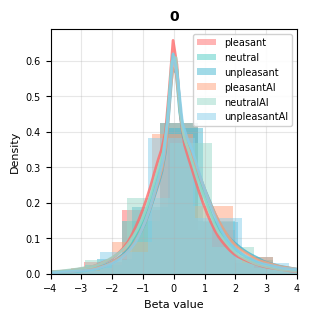

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_subject_distributions(beta_flat_avg, avg_meta, selected_subs):
    """
    Create 5x6 subplot figure with beta-value distributions for each subject
    Each subplot shows 6 distributions (one per condition) in different colors
    """
    
    # Define colors for each condition
    condition_colors = {
        'pleasant': '#FF6B6B',      # Red
        'neutral': '#4ECDC4',       # Teal
        'unpleasant': '#45B7D1',    # Blue
        'pleasantAI': '#FFA07A',    # Light Red
        'neutralAI': '#98D8C8',     # Light Teal
        'unpleasantAI': '#87CEEB'   # Sky Blue
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(7, 7))
    axes = axes.flatten()
    
    group_order = ['pleasant', 'neutral', 'unpleasant', 
                   'pleasantAI', 'neutralAI', 'unpleasantAI']
    
    for subj_idx in range(len(selected_subs)):
        ax = axes[subj_idx]
        condition_data = {}
        
        for group in group_order:
            group_mask = avg_meta['group'] == group
            group_indices = np.where(group_mask)[0]
            group_beta_values = beta_flat_avg[subj_idx, group_indices, :].flatten()
            group_beta_values = group_beta_values[~np.isnan(group_beta_values)]
            
            if len(group_beta_values) > 100000:
                np.random.seed(42)
                group_beta_values = np.random.choice(group_beta_values, 100000, replace=False)
            
            condition_data[group] = group_beta_values
        
        for group in group_order:
            if len(condition_data[group]) > 0:
                ax.hist(condition_data[group],
                        bins=20,
                        alpha=0.5,
                        color=condition_colors[group],
                        label=group,
                        density=True,
                        histtype='stepfilled')
                
                from scipy import stats
                density = stats.gaussian_kde(condition_data[group])
                xs = np.linspace(condition_data[group].min(),
                                 condition_data[group].max(), 200)
                ax.plot(xs, density(xs), color=condition_colors[group],
                        linewidth=2, alpha=0.8)
        
        ax.set_title(f'{selected_subs[subj_idx]}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Beta value', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_xlim(-4, 4)
        ax.grid(True, alpha=0.3)
        
        if subj_idx == 0:
            ax.legend(loc='upper right', fontsize=7, framealpha=0.9)
    
    for i in range(len(selected_subs), 30):
        axes[i].set_visible(False)
    
    fig.suptitle('Beta Value Distributions by Subject and Condition',
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.savefig('subject_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary stats
    print("\n" + "="*60)
    print("DISTRIBUTION SUMMARY STATISTICS")
    print("="*60)
    for subj_idx in range(min(3, len(selected_subs))):
        print(f"\n{selected_subs[subj_idx]}:")
        for group in group_order:
            group_mask = avg_meta['group'] == group
            group_indices = np.where(group_mask)[0]
            group_beta_values = beta_flat_avg[subj_idx, group_indices, :].flatten()
            group_beta_values = group_beta_values[~np.isnan(group_beta_values)]
            
            if len(group_beta_values) > 0:
                print(f"  {group:15s}: mean={np.mean(group_beta_values):6.3f}, "
                      f"std={np.std(group_beta_values):6.3f}, "
                      f"n={len(group_beta_values):,}")

# Create the plot
plot_subject_distributions(beta_flat_avg2, avg_meta, selected_subs)


In [33]:
import os
import numpy as np
import pandas as pd
import nibabel as nib

# ------------------------------------------------------------
# REQUIRED INPUTS
#   beta_flat_avg : np.ndarray, (S, 120, V)  # e.g., (30, 120, 592895)
#   avg_meta      : pd.DataFrame with columns ['out_col','group','img',...]
#                   where 'out_col' maps 0..119 to beta_flat_avg columns
#   ref_img       : nib.Nifti1Image (same grid as the flattened V)
#   output_dir    : folder to write NIfTIs
# ------------------------------------------------------------

def save_group_averages(beta_flat_avg, avg_meta, ref_img, output_dir,
                        save_std=False,
                        group_order=('pleasant','neutral','unpleasant',
                                     'pleasantAI','neutralAI','unpleasantAI')):
    os.makedirs(output_dir, exist_ok=True)
    
    S, C, V = beta_flat_avg.shape
    grid_shape = ref_img.shape
    assert np.prod(grid_shape) == V, "ref_img grid size must match flattened V."

    # Use ref_img header/affine (like your example)
    affine = ref_img.affine
    header = ref_img.header.copy()
    header.set_data_dtype(np.float32)

    # Ensure we can map groups -> column indices in beta_flat_avg
    if 'out_col' not in avg_meta.columns:
        raise ValueError("avg_meta must contain 'out_col' column mapping 0..119.")
    if 'group' not in avg_meta.columns:
        raise ValueError("avg_meta must contain 'group' column.")

    for g in group_order:
        # Columns for this group (20 images)
        cols = avg_meta.loc[avg_meta['group'] == g, 'out_col'].to_numpy()
        if len(cols) != 20:
            raise ValueError(f"Group '{g}' should have 20 items; found {len(cols)}.")

        # Slice → (S, 20, V); average over subjects and items → (V,)
        sub = beta_flat_avg[:, cols, :]  # (S, 20, V)
        mean_map = np.nanmean(sub, axis=(0, 1)).astype(np.float32)  # (V,)

        # Reshape to 3D and save
        mean_vol = mean_map.reshape(grid_shape)
        mean_nifti = nib.Nifti1Image(mean_vol, affine, header)
        mean_filename = os.path.join(output_dir, f"{g}_mean.nii.gz")
        nib.save(mean_nifti, mean_filename)
        print(f"Saved: {mean_filename}")

        if save_std:
            std_map = np.nanstd(sub, axis=(0, 1)).astype(np.float32)  # (V,)
            std_vol = std_map.reshape(grid_shape)
            std_nifti = nib.Nifti1Image(std_vol, affine, header)
            std_filename = os.path.join(output_dir, f"{g}_std.nii.gz")
            nib.save(std_nifti, std_filename)
            print(f"Saved: {std_filename}")

# ------------------ EXAMPLE CALL ------------------
save_group_averages(beta_flat_avg2, avg_meta, resampled_mask, "./group_maps/sub31_2", save_std=False)
# If your reference is named ref_img instead of resampled_mask:
# save_group_averages(beta_flat_avg, avg_meta, ref_img, "./group_maps", save_std=False)


Saved: ./group_maps/sub31_2\pleasant_mean.nii.gz
Saved: ./group_maps/sub31_2\neutral_mean.nii.gz
Saved: ./group_maps/sub31_2\unpleasant_mean.nii.gz
Saved: ./group_maps/sub31_2\pleasantAI_mean.nii.gz
Saved: ./group_maps/sub31_2\neutralAI_mean.nii.gz
Saved: ./group_maps/sub31_2\unpleasantAI_mean.nii.gz
